<a href="https://colab.research.google.com/github/RAJANIKANT2907/Data-Science-Projects-and-Assignments/blob/main/NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/amazonreviews.tsv', sep='\t')

# Display the first 5 rows of the DataFrame
display(df.head())

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [2]:
# Display concise summary of the DataFrame
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


None

In [3]:
# Check the distribution of the target variable 'label'
display(df['label'].value_counts())

,count
label,
neg,5097
pos,4903


In [4]:
# Check for duplicate reviews
duplicates_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates_count}")

# Remove duplicate rows if any
if duplicates_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")
    print(f"New number of rows: {len(df)}")
else:
    print("No duplicate rows found.")

Number of duplicate rows: 0
No duplicate rows found.


In [5]:
# Check for missing values in the 'review' column
missing_reviews = df['review'].isnull().sum()
print(f"Number of missing reviews: {missing_reviews}")

# Handle missing reviews (e.g., drop rows with missing reviews)
if missing_reviews > 0:
    df.dropna(subset=['review'], inplace=True)
    print("Rows with missing reviews removed.")
    print(f"New number of rows: {len(df)}")
else:
    print("No missing reviews found.")

Number of missing reviews: 0
No missing reviews found.


In [6]:
import nltk
from nltk.corpus import stopwords
import string

nltk.download('stopwords')
nltk.download('punkt')

# Convert text to lowercase
df['review_cleaned'] = df['review'].apply(lambda x: x.lower())

# Remove punctuation (optional, but often helpful)
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))
df['review_cleaned'] = df['review_cleaned'].apply(remove_punctuation)

# Remove stopwords
stop_words = set(stopwords.words('english'))
def remove_stopwords(text):
    return ' '.join([word for word in str(text).split() if word not in stop_words])
df['review_cleaned'] = df['review_cleaned'].apply(remove_stopwords)

# Display the first few cleaned reviews
display(df[['review', 'review_cleaned']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


,review,review_cleaned
0,Stuning even for the non-gamer: This sound tra...,stuning even nongamer sound track beautiful pa...
1,The best soundtrack ever to anything.: I'm rea...,best soundtrack ever anything im reading lot r...
2,Amazing!: This soundtrack is my favorite music...,amazing soundtrack favorite music time hands i...
3,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack truly like soundtrack enj...
4,"Remember, Pull Your Jaw Off The Floor After He...",remember pull jaw floor hearing youve played g...


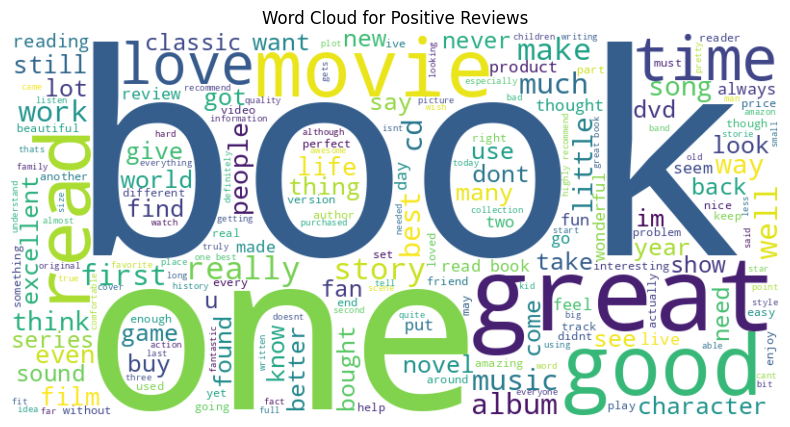

In [7]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Separate reviews by sentiment
positive_reviews = df[df['label'] == 'pos']['review_cleaned']
negative_reviews = df[df['label'] == 'neg']['review_cleaned']

# Generate word cloud for positive reviews
positive_text = ' '.join(positive_reviews)
wordcloud_positive = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Positive Reviews')
plt.show()

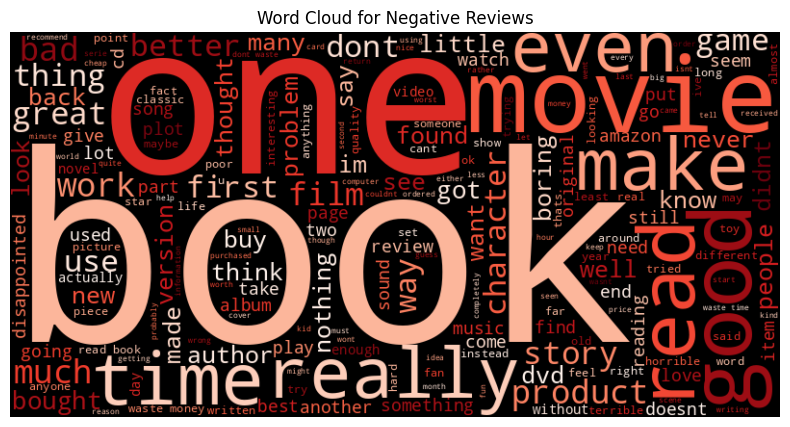

In [8]:
# Generate word cloud for negative reviews
negative_text = ' '.join(negative_reviews)
wordcloud_negative = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(negative_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Negative Reviews')
plt.show()

In [9]:
from collections import Counter

# Tokenize and count words for positive reviews
positive_words = ' '.join(positive_reviews).split()
positive_word_counts = Counter(positive_words)

# Display top 10 most common positive words
print("\nTop 10 Most Common Words in Positive Reviews:")
for word, count in positive_word_counts.most_common(10):
    print(f"{word}: {count}")

# Tokenize and count words for negative reviews
negative_words = ' '.join(negative_reviews).split()
negative_word_counts = Counter(negative_words)

# Display top 10 most common negative words
print("\nTop 10 Most Common Words in Negative Reviews:")
for word, count in negative_word_counts.most_common(10):
    print(f"{word}: {count}")


Top 10 Most Common Words in Positive Reviews:
book: 3313
great: 2087
one: 1835
good: 1634
read: 1553
like: 1268
movie: 1079
would: 943
love: 902
time: 871

Top 10 Most Common Words in Negative Reviews:
book: 3183
one: 2022
like: 1546
movie: 1464
would: 1438
dont: 1240
read: 1187
get: 1139
good: 1134
time: 1032


### Model Development

Now that the data is cleaned and we have some insights from the exploratory analysis, let's proceed with building a sentiment analysis model. We'll use TF-IDF for feature extraction and a Logistic Regression classifier as a baseline model.

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Separate features (X) and target (y)
X = df['review_cleaned']
y = df['label']

# Encode labels to numerical format
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting features to 5000 for efficiency

# Fit and transform the training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform the test data
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"TF-IDF features for training set shape: {X_train_tfidf.shape}")
print(f"TF-IDF features for testing set shape: {X_test_tfidf.shape}")

Training set size: 8000
Testing set size: 2000
TF-IDF features for training set shape: (8000, 5000)
TF-IDF features for testing set shape: (2000, 5000)


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000, random_state=42) # Increased max_iter for convergence
log_reg_model.fit(X_train_tfidf, y_train)

# Make predictions on the test set
y_pred = log_reg_model.predict(X_test_tfidf)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8515

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.86      0.85      1019
           1       0.85      0.85      0.85       981

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



### Model Development: Support Vector Machine (SVM)

Let's try a Support Vector Machine (SVM) classifier. SVMs are powerful models that can find complex decision boundaries, which can be beneficial for text classification.

In [18]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train the Support Vector Machine model
svm_model = SVC(kernel='linear', random_state=42) # Using a linear kernel for text data
svm_model.fit(X_train_tfidf, y_train)

# Make predictions on the test set
y_pred_svm = svm_model.predict(X_test_tfidf)

# Evaluate the SVM model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {accuracy_svm:.4f}")

print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.8600

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.86      0.86      1019
           1       0.85      0.86      0.86       981

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000



### Model Development: Neural Network (Multi-Layer Perceptron)

Now, let's explore a Neural Network model using a Multi-Layer Perceptron (MLP) classifier. Neural networks can learn more complex relationships in the data, potentially leading to improved performance.

In [15]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train the MLP Classifier
# We'll use a simple architecture with one hidden layer for a start.
mlp_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42, early_stopping=True, n_iter_no_change=10)
mlp_model.fit(X_train_tfidf, y_train)

# Make predictions on the test set
y_pred_mlp = mlp_model.predict(X_test_tfidf)

# Evaluate the MLP model
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
print(f"MLP Accuracy: {accuracy_mlp:.4f}")

print("\nMLP Classification Report:")
print(classification_report(y_test, y_pred_mlp))

MLP Accuracy: 0.8520

MLP Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.85      1019
           1       0.85      0.85      0.85       981

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



### Model Comparison: Confusion Matrices

To better understand the performance of each model beyond simple accuracy, let's visualize their predictions using confusion matrices. A confusion matrix shows the number of correct and incorrect predictions for each class, providing insights into where the models might be struggling (e.g., misclassifying positive reviews as negative).

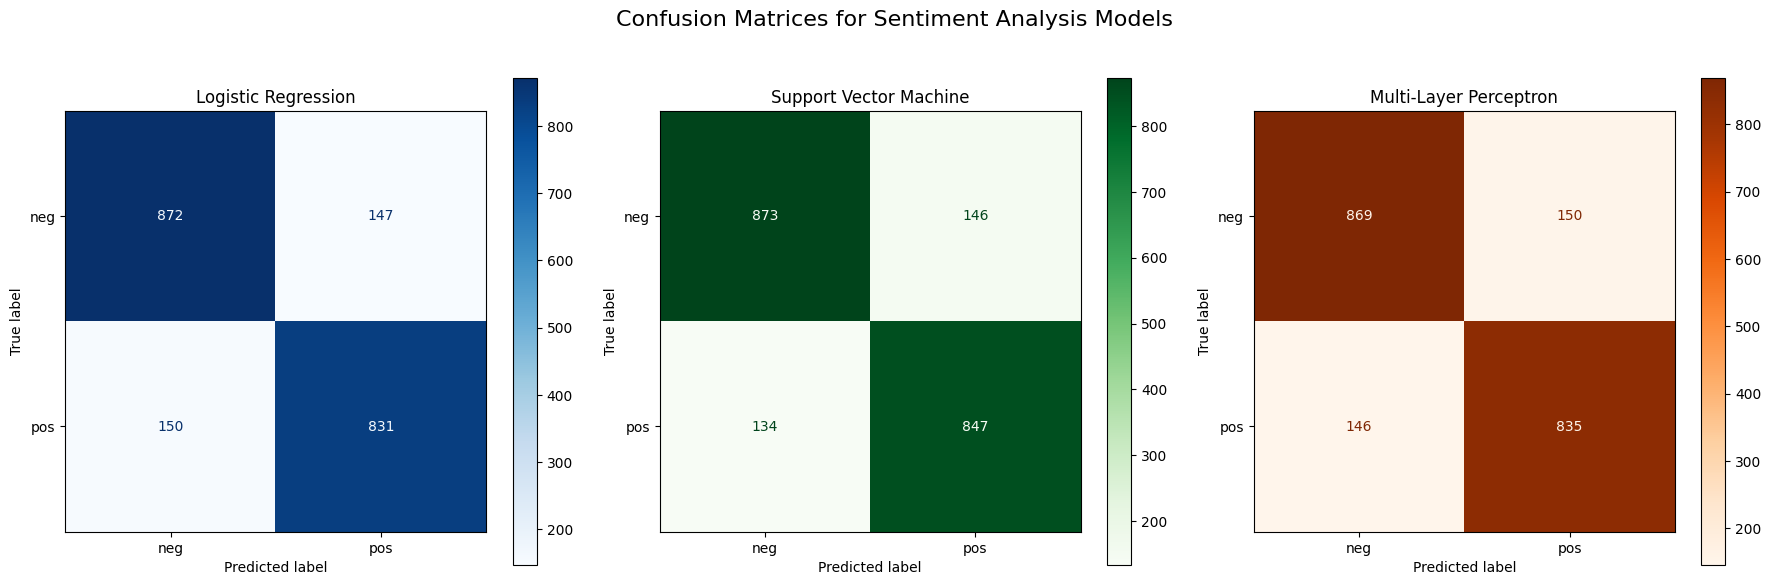

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create a figure with subplots for each confusion matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Confusion Matrices for Sentiment Analysis Models', fontsize=16)

# Logistic Regression Confusion Matrix
ConfusionMatrixDisplay.from_estimator(log_reg_model, X_test_tfidf, y_test, cmap=plt.cm.Blues, ax=axes[0], display_labels=label_encoder.classes_)
axes[0].set_title('Logistic Regression')

# SVM Confusion Matrix
ConfusionMatrixDisplay.from_estimator(svm_model, X_test_tfidf, y_test, cmap=plt.cm.Greens, ax=axes[1], display_labels=label_encoder.classes_)
axes[1].set_title('Support Vector Machine')

# MLP Confusion Matrix
ConfusionMatrixDisplay.from_estimator(mlp_model, X_test_tfidf, y_test, cmap=plt.cm.Oranges, ax=axes[2], display_labels=label_encoder.classes_)
axes[2].set_title('Multi-Layer Perceptron')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Model Optimization: Hyperparameter Tuning (SVM)

To further improve the performance of our best model, the Support Vector Machine (SVM), we will perform hyperparameter tuning using `GridSearchCV`. This process will help us find the optimal combination of parameters that lead to the best classification accuracy on our dataset.

In [20]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Define the parameter grid for GridSearchCV
param_grid = {
    'C': [0.1, 1, 10, 100],  # Regularization parameter
    'kernel': ['linear', 'rbf'] # Kernel type
}

# Initialize GridSearchCV
# We'll use a smaller cv value for faster execution, but in a real scenario, use 5 or 10.
grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train_tfidf, y_train)

# Print the best parameters found
print(f"Best Parameters: {grid_search.best_params_}")

# Get the best estimator (model) from GridSearchCV
best_svm_model = grid_search.best_estimator_

# Make predictions on the test set using the best model
y_pred_best_svm = best_svm_model.predict(X_test_tfidf)

# Evaluate the best SVM model
accuracy_best_svm = accuracy_score(y_test, y_pred_best_svm)
print(f"\nOptimized SVM Accuracy: {accuracy_best_svm:.4f}")

print("\nOptimized SVM Classification Report:")
print(classification_report(y_test, y_pred_best_svm))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters: {'C': 1, 'kernel': 'rbf'}

Optimized SVM Accuracy: 0.8560

Optimized SVM Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1019
           1       0.85      0.86      0.85       981

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000



After hyperparameter tuning, we can see if the SVM model's performance has improved. It's often beneficial to visualize the confusion matrix for the optimized model as well, to compare it with the previous one.

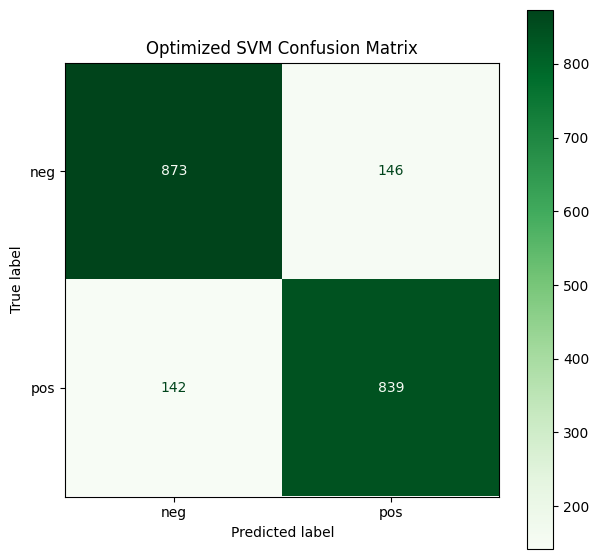

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Plot Confusion Matrix for the Optimized SVM Model
fig, ax = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay.from_estimator(best_svm_model, X_test_tfidf, y_test, cmap=plt.cm.Greens, ax=ax, display_labels=label_encoder.classes_)
ax.set_title('Optimized SVM Confusion Matrix')
plt.show()